#### **Polynomial Regression Project: Student Performance Growth Analysis :**

#### **Problem Statement: Analyze non-linear relationship between study hours and exam scores.**

In [26]:
# Step No 1 : Import required libraries
# import numerical library 
import numpy as np 

# Import pandas library 
import pandas as pd 

# Import plotting libarary 
import matplotlib.pyplot as plt

# Import seaborn libarary
import seaborn as sns

# Import train test split 
from sklearn.model_selection import train_test_split

# Import linear Regression model 
from sklearn.linear_model import LinearRegression

# Import Polynomial Features 
from sklearn.preprocessing import PolynomialFeatures

# Import evaluation metrics 
from sklearn.metrics import mean_absolute_error , mean_squared_error,r2_score

In [27]:
# Step No 2 : Data Loading and Exploration
df = pd.read_csv("student_performance_dataset.csv")

In [28]:
# Step No 3 : Understanding the Data
# Display first rows 
print(df.head())

# Display statistical summary 
print(df.describe())

# Display dataset information 
print(df.info())

   StudyHours  ExamScore
0           1         35
1           2         38
2           3         42
3           4         48
4           5         55
       StudyHours  ExamScore
count    20.00000  20.000000
mean     10.50000  73.300000
std       5.91608  20.021304
min       1.00000  35.000000
25%       5.75000  61.000000
50%      10.50000  79.000000
75%      15.25000  89.500000
max      20.00000  96.000000
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20 entries, 0 to 19
Data columns (total 2 columns):
 #   Column      Non-Null Count  Dtype
---  ------      --------------  -----
 0   StudyHours  20 non-null     int64
 1   ExamScore   20 non-null     int64
dtypes: int64(2)
memory usage: 452.0 bytes
None


In [29]:
# Step No 4 : Data Cleaning and Preprocessing
# Check missing values 
print(df.isnull().sum())

# Check duplicate rows 
print(df.duplicated().sum())

# Remove duplicate rows 
df = df.drop_duplicates()

StudyHours    0
ExamScore     0
dtype: int64
0


In [30]:
# Step No 5 : Features and Target Splitting
# Step No 16 : Define input feature
X = df[["StudyHours"]]

# Step No 17 : Define target variable
y = df["ExamScore"]


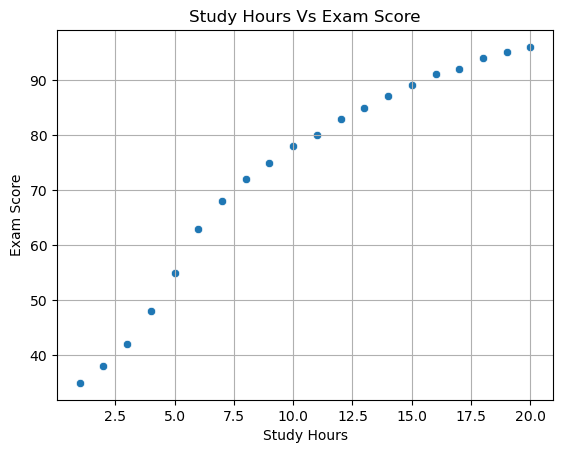

In [31]:
# Step No 6 : Visualization
sns.scatterplot(x="StudyHours" , y="ExamScore" , data=df)

# Set Plot title
plt.title("Study Hours Vs Exam Score")

# Set x-axis label
plt.xlabel("Study Hours")

# Set y-axis label
plt.ylabel("Exam Score")

# Enable grid 
plt.grid()

# Savefigure 
plt.savefig("images/Study Hours Vs Exam Score(PolynomialFeatures).png")

# Display plot 
plt.show()

In [32]:
# Step No 7 : Polynomial Feature Transformation

# Create polynomial features 
poly = PolynomialFeatures(degree=2)

# Transform input data 
X_poly = poly.fit_transform(X)

In [33]:
# Step No 8 : Train Test Split for Model Evaluation
X_train , X_test , y_train , y_test = train_test_split(
    X_poly,
    y,
    test_size=0.2,
    random_state=42
)

In [34]:
# Step No 9 : Initialize Model
model = LinearRegression()

In [35]:
# Step No 10 : Model Training
model.fit(X_train , y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [36]:
# Step No 11 : Prediction
y_pred = model.predict(X_test)

# Display predicted values 
print("Predicted Exam Scores : ")
print(y_pred)

Predicted Exam Scores : 
[31.11597345 93.84803069 91.96339478 37.73708439]


In [37]:
# Step No 12 : Model Evaluation

# Calculate MAE
print("Mean Absolute Error : ")
print(mean_absolute_error(y_test , y_pred))

# Calculate MSE
print("Mean Squared Error : ")
print(mean_squared_error(y_test , y_pred))

# Calculate RMSE
print("Root Mean Squared Error : ") 
print(np.sqrt(mean_squared_error(y_test , y_pred)))

# Calculate R2 Score 
print("R2 Score : ")
print(r2_score(y_test , y_pred))

Mean Absolute Error : 
1.315576561445722
Mean Squared Error : 
4.026502754903703
Root Mean Squared Error : 
2.0066147499965465
R2 Score : 
0.994878851822062


c:\Users\sagar\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but PolynomialFeatures was fitted with feature names
  warnings.warn(


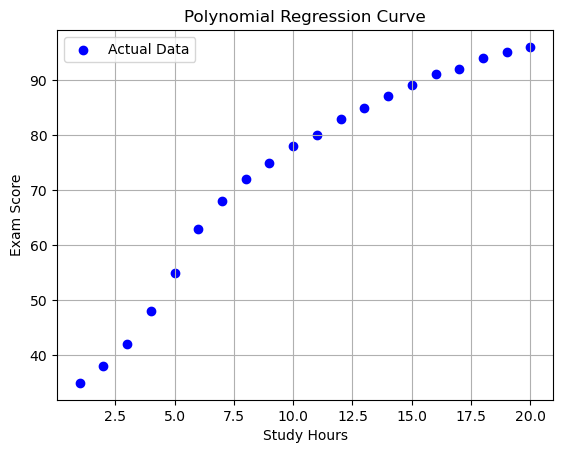

In [38]:
# Step No 13 : Polynomial Curve Visualization

# Create smooth curve values 
X_grid = np.linspace(X.min() , X.max() , 100).reshape(-1 , 1)

# Transform curve values 
X_grid_poly = poly.transform(X_grid)

# Predict curve points 
y_grid_pred = model.predict(X_grid_poly)

# Plot Actual data 
plt.scatter(X , y , color = "blue" , label = "Actual Data")

# Set Plot title 
plt.title("Polynomial Regression Curve")

# Set x-axis label
plt.xlabel("Study Hours")

# Set y-axis label 
plt.ylabel("Exam Score")

# Display legend 
plt.legend()

# Enable grid 
plt.grid()

# Save figure 
plt.savefig("images/Polynomial Regression Curve.png")

# display the output 
plt.show()

In [39]:
# Step No 14 : User Input
study_hours = float(input("Enter Study Hours : "))

In [40]:
# Step No 15 : Prediction on User Input

# Convert Input into array 
user_data = np.array([[study_hours]])

# Transform user input
user_data_poly = poly.transform(user_data)

# Predict exam score 
result = model.predict(user_data_poly)

c:\Users\sagar\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but PolynomialFeatures was fitted with feature names
  warnings.warn(


In [41]:
# Step No 16 : Final Output
print(f"Predicted Exam Score is : {result[0]:.2f}")

Predicted Exam Score is : 55.40
